In [10]:
# Install RDKit first if needed:
# conda install -c conda-forge rdkit

import pandas as pd
from rdkit import Chem

# === Step 1: Load your dataset ===
# 🔹 Replace with your actual file path
file_path = r"C:/Users/HP/Downloads/qm133885_properties.csv"
df = pd.read_csv(file_path)

# Check column names
print("Columns found:", df.columns.tolist())

# === Step 2: Function to extract atom types from one SMILES ===
def get_atom_types(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return set()
        return set(atom.GetSymbol() for atom in mol.GetAtoms())
    except:
        return set()

# === Step 3: Apply function to entire dataset ===
all_atom_types = set()

for smiles in df["SMILES"]:
    atom_set = get_atom_types(smiles)
    all_atom_types.update(atom_set)

# === Step 4: Display and optionally save the result ===
print("\n✅ Unique atom types found in the dataset:")
print(sorted(all_atom_types))

# Optional: Save to a text file
with open("unique_atom_types.txt", "w") as f:
    f.write(", ".join(sorted(all_atom_types)))

print("\nSaved to 'unique_atom_types.txt'")


Columns found: ['A', 'B', 'C', 'mu', 'alpha', 'HOMO', 'LUMO', 'gap', 'R2', 'ZPVE', 'U0', 'U', 'H', 'G', 'Cv', 'SMILES']

✅ Unique atom types found in the dataset:
['C', 'F', 'N', 'O']

Saved to 'unique_atom_types.txt'


In [23]:
import pandas as pd
from rdkit import Chem
import os

# === Step 1: Load dataset ===
file_path = r"C:/Users/HP/Downloads/qm133885_properties.csv"
df = pd.read_csv(file_path)

print("Columns available:", df.columns.tolist())
print("Total molecules in dataset:", len(df))

# === Step 2: Function to check if only 'C' atoms are present ===
def carbon_oxygen_nitrogen_fluoride(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return False
        atom_types = set(atom.GetSymbol() for atom in mol.GetAtoms())
        return atom_types.issubset({"C", "O","F","N"})  # only C and O allowed
    except:
        return False

# === Step 3: Filter molecules with only carbon ===
column_name = "SMILES"  # change if your column name is different
df_only_c = df[df[column_name].apply(carbon_oxygen_nitrogen_fluoride)]

print("✅ Molecules with only carbon atoms:", len(df_only_c))

# === Step 4: Save the result ===
output_path = os.path.join(os.path.dirname(file_path), "C_O_N_F_molecules.csv")
df_only_c.to_csv(output_path, index=False)
print(f"🎉 Saved to '{output_path}'")


Columns available: ['A', 'B', 'C', 'mu', 'alpha', 'HOMO', 'LUMO', 'gap', 'R2', 'ZPVE', 'U0', 'U', 'H', 'G', 'Cv', 'SMILES']
Total molecules in dataset: 133885
✅ Molecules with only carbon atoms: 133885
🎉 Saved to 'C:/Users/HP/Downloads\C_O_N_F_molecules.csv'


In [5]:
import pandas as pd
from rdkit import Chem
import os

# === Step 1: Load your dataset ===
file_path = r"C:/Users/HP/Downloads/only_carbon_molecules.csv"
df = pd.read_csv(file_path)

print("✅ File loaded successfully.")
print("Columns found:", df.columns.tolist())
print("Total rows before cleaning:", len(df))

# === Step 2: Function to check if SMILES is valid ===
def is_valid_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

# === Step 3: Apply validation ===
column_name = "SMILES"  # change if your column is named differently, e.g. "SMILES"
df_clean = df[df[column_name].apply(is_valid_smiles)]

print("✅ Rows after removing invalid SMILES:", len(df_clean))
print("🧹 Removed", len(df) - len(df_clean), "invalid or inconsistent entries")

# === Step 4: Remove duplicates (optional) ===
df_clean = df_clean.drop_duplicates(subset=[column_name])
print("✅ Rows after removing duplicates:", len(df_clean))

# === Step 5: Save the cleaned dataset ===
output_path = os.path.join(os.path.dirname(file_path), "cleaned_dataset.csv")
df_clean.to_csv(output_path, index=False)
print(f"🎉 Cleaned dataset saved to: {output_path}")


✅ File loaded successfully.
Columns found: ['A', 'B', 'C', 'mu', 'alpha', 'HOMO', 'LUMO', 'gap', 'R2', 'ZPVE', 'U0', 'U', 'H', 'G', 'Cv', 'SMILES']
Total rows before cleaning: 4907
✅ Rows after removing invalid SMILES: 4907
🧹 Removed 0 invalid or inconsistent entries
✅ Rows after removing duplicates: 4907
🎉 Cleaned dataset saved to: C:/Users/HP/Downloads\cleaned_dataset.csv


In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer, StandardScaler

# Load dataset
data = pd.read_csv("C_O_N_F_molecules.csv")

# Select only numeric columns (properties)
numeric_cols = data.select_dtypes(include=[np.number]).columns

print("Numeric columns to linearize:")
print(numeric_cols)

# ----- STEP 1: POWER TRANSFORM (Linearization) -----
pt = PowerTransformer(method='yeo-johnson')

data_linearized = data.copy()
data_linearized[numeric_cols] = pt.fit_transform(data[numeric_cols])

# ----- STEP 2: STANDARDIZATION (Optional but good for ML) -----
scaler = StandardScaler()
data_linearized[numeric_cols] = scaler.fit_transform(data_linearized[numeric_cols])

# Save the transformed dataset
data_linearized.to_csv("linearized_dataset.csv", index=False)

print("\nDataset successfully linearized and saved as linearized_dataset.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'C_O_N_F.csv'

In [2]:
from rdkit import Chem
import pandas as pd

data = pd.read_csv("only_carbon_molecules.csv")

def to_canonical(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True)

data["canonical_smiles"] = data["SMILES"].apply(to_canonical)

total_smiles = len(data)
unique_molecules = data["canonical_smiles"].nunique()
duplicate_molecules = total_smiles - unique_molecules

print(f"Total SMILES: {total_smiles}")
print(f"Unique molecules (canonical): {unique_molecules}")
print(f"Duplicate molecules: {duplicate_molecules}")



Total SMILES: 4907
Unique molecules (canonical): 4907
Duplicate molecules: 0


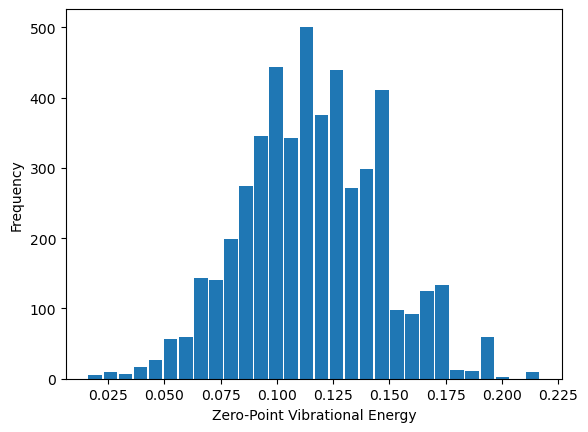

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv("C_O_N_F_molecules.csv").iloc[:4907]
y = data["ZPVE"] 
plt.figure()
plt.hist(y, bins=30, rwidth=0.9)
plt.xlabel("Zero-Point Vibrational Energy")
plt.ylabel("Frequency")
plt.show()


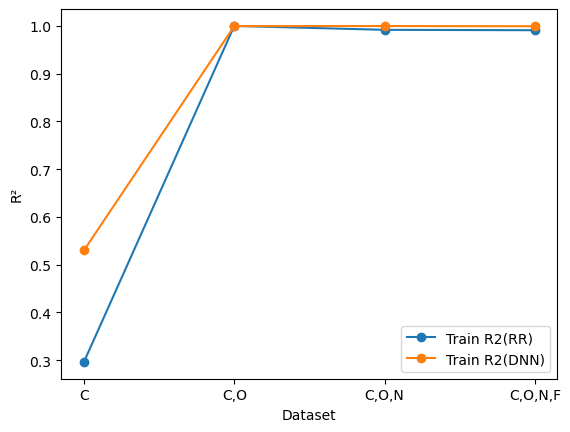

In [4]:
import matplotlib.pyplot as plt

# Dataset names
datasets = ["C", "C,O", "C,O,N", "C,O,N,F"]

# R2 values
train_rg = [0.2965,1,0.9918,0.9910]
train_dn = [0.5301,0.9997,0.9998,0.9994]
test_rg = [-0.2024,1,0.9966,0.9956]
test_dn = [-0.2013,0.5455,0.9976,0.9837]

plt.figure()
plt.plot(datasets, train_rg, marker='o', label="Train R2(RR)")
plt.plot(datasets, train_dn, marker='o', label="Train R2(DNN)")
#plt.plot(datasets, test_rg,  marker='s', label="Test R2(RR)")
#plt.plot(datasets, test_dn,  marker='s', label="Test R2(DNN)")


plt.xlabel("Dataset")
plt.ylabel("R²")
plt.legend()
plt.show()


In [28]:
# ===================== IMPORT LIBRARIES =====================
import pandas as pd
import numpy as np
from scipy.stats import entropy
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import RDLogger
import warnings

warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

# ===================== LOAD DATA =====================
data = pd.read_csv("C_O_N_F_molecules.csv")

smiles = data["SMILES"].values

# ===================== SMILES → MORGAN FINGERPRINT =====================
def smiles_to_fingerprint(smiles_string, n_bits=512):
    mol = Chem.MolFromSmiles(smiles_string)
    if mol is None:
        return np.zeros(n_bits, dtype=int)

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol, radius=2, nBits=n_bits
    )
    return np.array(fp, dtype=int)

X = np.array([smiles_to_fingerprint(sm) for sm in smiles])

print("Original fingerprint matrix shape:", X.shape)

 #===================== BIT-WISE SHANNON ENTROPY =====================
bit_entropies = []

for bit_idx in range(X.shape[1]):
    bit_column = X[:, bit_idx]
    values, counts = np.unique(bit_column, return_counts=True)
    probabilities = counts / counts.sum()
    bit_entropy = entropy(probabilities, base=2)
    bit_entropies.append(bit_entropy)

bit_entropies = np.array(bit_entropies)

# ===================== ENTROPY-BASED BIT REDUCTION =====================
entropy_threshold = 0.02   # can be tuned (0.3–0.7 typical)

selected_bit_indices = np.where(bit_entropies > entropy_threshold)[0]
X_reduced = X[:, selected_bit_indices]

# ===================== ENTROPY COMPARISON =====================
reduced_bit_entropies = bit_entropies[selected_bit_indices]

print("\n==================== ENTROPY COMPARISON ====================")
print(f"Entropy threshold used       : {entropy_threshold}")
print(f"Original fingerprint bits    : {X.shape[1]}")
print(f"Retained fingerprint bits    : {len(selected_bit_indices)}")

print(f"\nMean entropy (original)      : {np.mean(bit_entropies):.4f} bits")
print(f"Mean entropy (reduced)       : {np.mean(reduced_bit_entropies):.4f} bits")

print(f"\nTotal entropy (original)     : {np.sum(bit_entropies):.2f} bits")
print(f"Total entropy (reduced)      : {np.sum(reduced_bit_entropies):.2f} bits")

# Flatten all bits in dataset
all_bits = X.flatten()

values, counts = np.unique(all_bits, return_counts=True)
probabilities = counts / counts.sum()

global_entropy = entropy(probabilities, base=2)
print("Global Fingerprint Entropy (whole dataset) =", global_entropy)


# ===================== OPTIONAL: SAVE REDUCED FEATURES =====================
# np.save("X_morgan_entropy_reduced.npy", X_reduced)
# np.save("selected_bit_indices.npy", selected_bit_indices)

#print("\nReduced fingerprint matrix shape:", X_reduced.shape)


Original fingerprint matrix shape: (133885, 512)

==================== ENTROPY COMPARISON ====================
Entropy threshold used       : 0.02
Original fingerprint bits    : 512
Retained fingerprint bits    : 512

Mean entropy (original)      : 0.1981 bits
Mean entropy (reduced)       : 0.1981 bits

Total entropy (original)     : 101.43 bits
Total entropy (reduced)      : 101.43 bits
Global Fingerprint Entropy (whole dataset) = 0.23926014845656876


In [32]:
# ===================== IMPORT LIBRARIES =====================
import pandas as pd
import numpy as np
from scipy.stats import entropy
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import RDLogger
import warnings

warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

# ===================== LOAD DATA =====================
data = pd.read_csv("carbon_oxygen_molecules.csv")
smiles = data["SMILES"]

# ===================== SMILES → MORGAN FINGERPRINT =====================
def smiles_to_fingerprint(sm, n_bits=2048):
    mol = Chem.MolFromSmiles(sm)
    if mol is None:
        return np.zeros(n_bits, dtype=int)
    return np.array(
        AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits)
    )

X = np.array([smiles_to_fingerprint(s) for s in smiles])

print("Original fingerprint shape:", X.shape)

# ===================== BIT-WISE SHANNON ENTROPY =====================
bit_entropies = []

for bit_idx in range(X.shape[1]):
    bit_column = X[:, bit_idx]
    values, counts = np.unique(bit_column, return_counts=True)
    probabilities = counts / counts.sum()
    bit_entropy = entropy(probabilities, base=2)
    bit_entropies.append(bit_entropy)

bit_entropies = np.array(bit_entropies)

# ===================== ENTROPY-BASED BIT REDUCTION =====================
# 🔧 Threshold (can be tuned)
entropy_threshold = 0.1


selected_bit_indices = np.where(bit_entropies > entropy_threshold)[0]

X_reduced = X[:, selected_bit_indices]

# ===================== OUTPUT =====================
print("\n==================== REDUCED BIT INFO ====================")
print("Entropy threshold used:", entropy_threshold)
print("Number of original bits:", X.shape[1])
print("Number of retained bits:", len(selected_bit_indices))

print("\nSelected bit indices:")
print(selected_bit_indices)

print("\nReduced fingerprint shape:", X_reduced.shape)

Original fingerprint shape: (50678, 2048)

==================== REDUCED BIT INFO ====================
Entropy threshold used: 0.1
Number of original bits: 2048
Number of retained bits: 172

Selected bit indices:
[   1   13   23   29   41   57   61   80  114  117  118  139  151  171
  176  196  221  222  225  226  227  231  242  283  287  294  308  314
  351  370  384  392  413  441  455  470  473  482  492  497  503  507
  508  515  519  523  528  547  550  585  598  609  610  611  622  650
  656  670  674  679  694  695  706  708  722  739  750  760  787  794
  795  798  802  807  832  841  848  849  854  888  900  909  915  918
  926  937  940  941  950  960  970  974 1004 1005 1009 1017 1019 1028
 1056 1057 1060 1063 1070 1083 1088 1128 1136 1147 1148 1154 1162 1170
 1181 1224 1238 1256 1257 1274 1292 1309 1325 1349 1351 1380 1383 1391
 1404 1413 1446 1454 1457 1477 1486 1487 1512 1516 1539 1544 1546 1549
 1564 1577 1584 1592 1648 1664 1693 1722 1730 1738 1781 1819 1855 1859
 1873 1

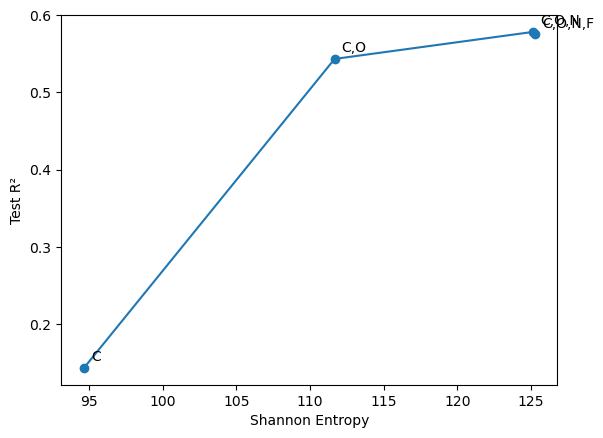

In [12]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ["C", "C,O", "C,O,N", "C,O,N,F"]

# R2 values
#train_r2 = [0.9373,0.9719,0.9941,0.9951]
test_r2  = [0.1431,0.5434,0.5784,0.5751]
#shannon_entropy = [0.0700,0.0771,0.0806,0.0805]
#shannon_entropy_mean = [0.0462,0.0545,0.0611,0.0612]
shannon_entropy_total = [94.65,111.67,125.14,125.27]

plt.figure()

plt.plot(shannon_entropy_total, test_r2,marker='o')
for i, label in enumerate(datasets):
    plt.annotate(
        label,
        (shannon_entropy_total[i], test_r2[i]),
        textcoords="offset points",
        xytext=(5, 5),
        ha="left"
    )
    
plt.xlabel("Shannon Entropy")
plt.ylabel("Test R²")
plt.show()

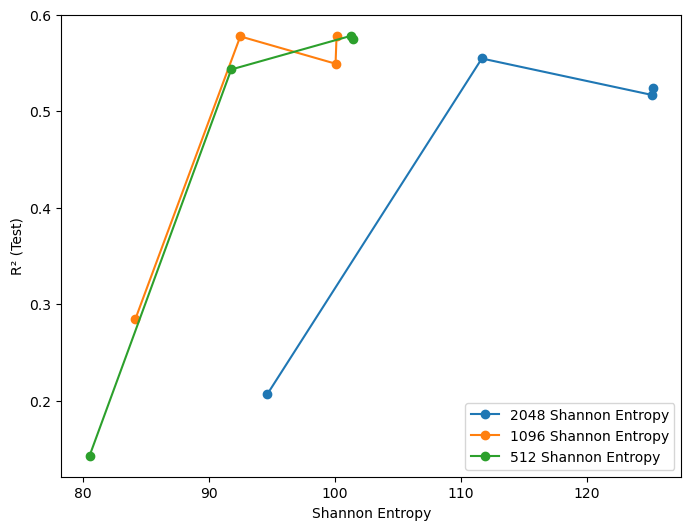

In [9]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ["C", "C,O", "C,O,N", "C,O,N,F"]

# R2 values
#train_2048 = [0.9197, 0.9935, 0.9948, 0.9936]
#train_1096 = [0.9611,0.9950,0.9926,0.9938]
#train_512 = [0.9373,0.9719,0.9941,0.9951]
test_2048 = [0.2070,0.5548,0.5171,0.5242]
test_1096 = [0.2850,0.5777,0.5494,0.5781]
test_512 = [0.1431,0.5434,0.5784,0.5751]

# Shannon entropy 
#shannon_mean_1096 = [0.0768,0.0844,0.0913,0.0914]
#shannon_mean_2048 = [0.0462,0.0545,0.0611,0.0612]
#shannon_mean_512 = [0.1573,0.1792,0.1979,0.1981]
shannon_total_2048 = [94.65,111.67,125.14,125.27] 
shannon_total_1096 = [84.18,92.50,100.06,100.14]
shannon_total_512 = [80.54,91.78,101.31,101.43]
#shannon_2048 = [0.0700,0.0771,0.0806,0.0805]
#shannon_1096 = [0.1114,0.1182,0.1203,0.1202]
#shannon_512 = [0.2109,0.2300,0.2394,0.2392] 

plt.figure(figsize=(8,6))

# Plot original entropy vs R2
plt.plot(shannon_total_2048, test_2048, marker='o', label='2048 Shannon Entropy')

# Plot reduced entropy vs R2
plt.plot(shannon_total_1096, test_1096, marker='o', label='1096 Shannon Entropy')
plt.plot(shannon_total_512, test_512, marker='o', label='512 Shannon Entropy')

# Labels and title
plt.xlabel("Shannon Entropy")
plt.ylabel("R² (Test)")
plt.legend()
plt.grid(False)
plt.savefig("Shannon_total_test_vs_R2.png", dpi=600, bbox_inches='tight')

plt.show()


In [16]:
# ===================== IMPORT LIBRARIES =====================
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import ConvertToNumpyArray
from rdkit import RDLogger

RDLogger.DisableLog("rdApp.*")

# ===================== LOAD DATA =====================
data = pd.read_csv("only_carbon_molecules.csv")
smiles_list = data["SMILES"].values

# ===================== FUNCTION =====================
def smiles_to_fingerprint(smiles_string, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles_string)
    if mol is None:
        return np.zeros(n_bits, dtype=int)

    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    ConvertToNumpyArray(fp, arr)
    return arr

X = np.array([smiles_to_fingerprint(sm) for sm in smiles_list])
pd.DataFrame(X).to_csv("all_molecules_bit_vectors.csv", index=False)
print("Successful")
# X = (num_molecules, 2048) fingerprint matrix

bit_indices_per_molecule = []

for i in range(X.shape[0]):
    on_bits = np.where(X[i] == 1)[0]   # column indices where bit = 1
    bit_indices_per_molecule.append(on_bits)

    print(f"Molecule {i+1} -> ON bit columns:", on_bits)
bit_df = pd.DataFrame({
    "SMILES": smiles_list,
    "ON_bits": [",".join(map(str, bits)) for bits in bit_indices_per_molecule]
})

bit_df.to_csv("molecule_on_bits.csv", index=False)
# X = (num_molecules, num_bits) fingerprint matrix

zero_columns = np.where(np.all(X == 0, axis=0))[0]

print("Columns that are ALL ZERO:")
print(zero_columns)
print("Total zero-only columns:", len(zero_columns))


FileNotFoundError: [Errno 2] No such file or directory: 'carbon_nitrogen_molecules.csv'

In [9]:
# ===================== IMPORT =====================
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import ConvertToNumpyArray

# ===================== LOAD DATA =====================
data = pd.read_csv("only_carbon_molecules.csv")

smiles_list = data["SMILES"].values

# ===================== FINGERPRINT FUNCTION =====================
def smiles_to_fingerprint(smiles_string, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles_string)
    if mol is None:
        return np.zeros(n_bits, dtype=int)

    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    ConvertToNumpyArray(fp, arr)
    return arr

# ===================== CREATE FP MATRIX =====================
X = np.array([smiles_to_fingerprint(sm) for sm in smiles_list])

# Convert FP to DataFrame
fp_df = pd.DataFrame(X, columns=[f"FP_{i}" for i in range(2048)])

# ===================== COLUMNS TO REMOVE =====================
cols_to_remove = [65,91,107,180,227,280,315,347,353,445,449,453,575,579,603,638,736,822,834,855,933,1094,1131,1174,1205,1289,1317,1409,1430,1435,1505,1548,1553,1604,1910]   # your bit columns

# Convert bit index → column names
fp_cols_to_remove = [f"FP_{c}" for c in cols_to_remove]

# ===================== REMOVE ONLY FP COLUMNS =====================
fp_df_clean = fp_df.drop(columns=fp_cols_to_remove)

# ===================== MERGE BACK WITH ORIGINAL PARAMETERS =====================
final_df = pd.concat([data, fp_df_clean], axis=1)

# ===================== SAVE =====================
final_df.to_csv("only_carbon_molecule_cleaned.csv", index=False)

print("✅ Saved with parameters + cleaned fingerprints")
print("Original FP shape:", fp_df.shape)
print("New FP shape:", fp_df_clean.shape)
print("Final dataset shape:", final_df.shape)
expected_cols = 2048 - len(zero_columns)
print("Expected columns:", expected_cols)
print("Actual columns:", X_clean.shape[1])

# 2) Check that removed columns really had no 1s
for c in zero_columns[:5]:
    print(f"Column {c} sum (should be 0):", np.sum(X[:, c]))

# ===================== SAVE CLEANED DATA =====================
df_clean = pd.DataFrame(X_clean)
df_clean.insert(0, "SMILES", smiles_list)   # keep SMILES

print("\n✅ Cleaned fingerprint dataset saved as only_carbon_morgan_cleaned.csv")

✅ Saved with parameters + cleaned fingerprints
Original FP shape: (4907, 2048)
New FP shape: (4907, 2013)
Final dataset shape: (4907, 2029)
Expected columns: 2013
Actual columns: 2013
Column 65 sum (should be 0): 0
Column 91 sum (should be 0): 0
Column 107 sum (should be 0): 0
Column 180 sum (should be 0): 0
Column 227 sum (should be 0): 0

✅ Cleaned fingerprint dataset saved as only_carbon_morgan_cleaned.csv


In [19]:
#code for finding number of ON(1) position
# ===================== IMPORT LIBRARIES =====================
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
from scipy.stats import entropy

# ===================== LOAD DATA =====================
# Use read_excel if file is .xls
data = pd.read_csv("only_carbon_molecules.csv")

# Shuffle dataset
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

# SMILES column name
smiles_list = data["SMILES"].tolist()

# ===================== FINGERPRINT PARAMETERS =====================
nBits = 512
radius = 2

# ===================== GENERATE MORGAN FINGERPRINTS =====================
fingerprints = []

for smi in smiles_list:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
        arr = np.zeros((nBits,), dtype=int)
        DataStructs.ConvertToNumpyArray(fp, arr)
        fingerprints.append(arr)
    else:
        fingerprints.append(np.zeros(nBits))

# Convert to numpy array
X = np.array(fingerprints)

print("Fingerprint shape:", X.shape)   # (molecules, 2048)

# ===================== PRINT ON BITS FOR EACH MOLECULE =====================
print("\n===== ON BIT POSITIONS FOR EACH MOLECULE =====")
bit_indices_per_molecule = []

for i in range(X.shape[0]):
    on_bits = np.where(X[i] == 1)[0]
    bit_indices_per_molecule.append(on_bits)
    print(f"Molecule {i+1} -> ON bits:", on_bits)

# ===================== COUNT NUMBER OF 1s PER MOLECULE =====================
bit_count = np.sum(X == 1, axis=1)

print("\n===== NUMBER OF ON BITS PER MOLECULE =====")
for i, c in enumerate(bit_count):
    print(f"Molecule {i+1} -> {c} ON bits")

# Convert ON bits to string (so Excel/CSV can store them)
on_bits_str = [",".join(map(str, bits)) for bits in bit_indices_per_molecule]

results = pd.DataFrame({
    "Molecule_ID": np.arange(1, X.shape[0] + 1),
    "ON_bits_count": bit_count,
    "ON_bits_positions": on_bits_str
})

# Save file
results.to_csv("fingerprint_on_bits_results.csv", index=False)
print("File saved: fingerprint_on_bits_results.csv")




Fingerprint shape: (4907, 512)

===== ON BIT POSITIONS FOR EACH MOLECULE =====
Molecule 1 -> ON bits: [  1  33  59  80  86 104 139 282 294 306 313 337 354 361 403 414 430 472
 490 507]
Molecule 2 -> ON bits: [ 33  36  56  59 104 122 123 138 241 253 285 337 397 403 414 425 429 504
 507]
Molecule 3 -> ON bits: [  7  13  33  36  42  59  66  87 114 135 141 219 227 244 250 268 337 414
 507]
Molecule 4 -> ON bits: [ 19  33  36  59  61  73 104 138 154 167 250 301 305 337 354 355 366 394
 414 428 484 507]
Molecule 5 -> ON bits: [ 25  33  46  70 104 123 130 167 186 202 245 337 351 356 360 414 443]
Molecule 6 -> ON bits: [ 33  73  80  95 110 132 174 226 268 285 294 318 349 355 391 414 430 454
 507]
Molecule 7 -> ON bits: [  1  33  81 110 161 174 177 193 253 268 283 285 342 348 349 414 507 509]
Molecule 8 -> ON bits: [  2   4  73 276 301 378 414 427 507 511]
Molecule 9 -> ON bits: [ 33  59  93 124 263 268 273 285 337 355 410 414 441 507]
Molecule 10 -> ON bits: [ 33  36  59  61 104 120 139 167 18

In [18]:
#Number of 0 and 1 
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import ConvertToNumpyArray
from rdkit import RDLogger

RDLogger.DisableLog("rdApp.*")

# ===================== LOAD DATA =====================
data = pd.read_csv("only_carbon_molecules.csv")
smiles_list = data["SMILES"].values

# ===================== FUNCTION =====================
def smiles_to_fingerprint(smiles_string, n_bits=30):
    mol = Chem.MolFromSmiles(smiles_string)
    
    if mol is None:
        return np.zeros(n_bits, dtype=int)

    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    ConvertToNumpyArray(fp, arr)
    
    return arr

# ===================== GENERATE FINGERPRINT MATRIX =====================
X = np.array([smiles_to_fingerprint(sm) for sm in smiles_list])

print("Fingerprint matrix shape:", X.shape)

# ===================== TOTAL 1s AND 0s =====================
total_ones = np.sum(X)
total_elements = X.size
total_zeros = total_elements - total_ones

print("\n===== OVERALL COUNTS =====")
print("Total bits:", total_elements)
print("Total 1s:", total_ones)
print("Total 0s:", total_zeros)

# ===================== PER MOLECULE =====================
ones_per_molecule = np.sum(X, axis=1)
zeros_per_molecule = X.shape[1] - ones_per_molecule

print("\n===== PER MOLECULE =====")
print("Average 1s per molecule:", np.mean(ones_per_molecule))
print("Average 0s per molecule:", np.mean(zeros_per_molecule))

# ===================== PER BIT POSITION =====================
ones_per_bit = np.sum(X, axis=0)
zeros_per_bit = X.shape[0] - ones_per_bit

print("\n===== PER BIT POSITION =====")
print("Average 1s per bit:", np.mean(ones_per_bit))
print("Average 0s per bit:", np.mean(zeros_per_bit))

# ===================== DENSITY & SPARSITY =====================
bit_density = total_ones / total_elements
bit_sparsity = total_zeros / total_elements

print("\n===== MATRIX PROPERTIES =====")
print("Bit Density (fraction of 1s):", bit_density)
print("Bit Sparsity (fraction of 0s):", bit_sparsity)

Fingerprint matrix shape: (4907, 30)

===== OVERALL COUNTS =====
Total bits: 147210
Total 1s: 63513
Total 0s: 83697

===== PER MOLECULE =====
Average 1s per molecule: 12.943346240065212
Average 0s per molecule: 17.056653759934786

===== PER BIT POSITION =====
Average 1s per bit: 2117.1
Average 0s per bit: 2789.9

===== MATRIX PROPERTIES =====
Bit Density (fraction of 1s): 0.4314448746688404
Bit Sparsity (fraction of 0s): 0.5685551253311596
